In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
# ============================================
# LOAD DATASET (FROM SKLEARN LIBRARY)
# ============================================

from sklearn.datasets import load_breast_cancer

def load_data():
    """
    Load dataset from sklearn (no internet, no file needed)
    """

    dataset = load_breast_cancer()

    # Convert to DataFrame
    data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    data['target'] = dataset.target

    print("Dataset loaded from sklearn successfully!")
    print(f"Shape: {data.shape}")

    return data

# Load dataset
data = load_data()

data.head()

Dataset loaded from sklearn successfully!
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# ============================================
# DATA CLEANING
# ============================================

def clean_data(df):
    """
    Handle missing values (if any)
    """
    print("Missing values before cleaning:\n", df.isnull().sum())

    # sklearn dataset usually has no missing values
    df = df.fillna(df.median(numeric_only=True))

    print("\nMissing values after cleaning:\n", df.isnull().sum())

    return df

data = clean_data(data)

Missing values before cleaning:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Missing values after cleaning:
 mean radius           


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness 

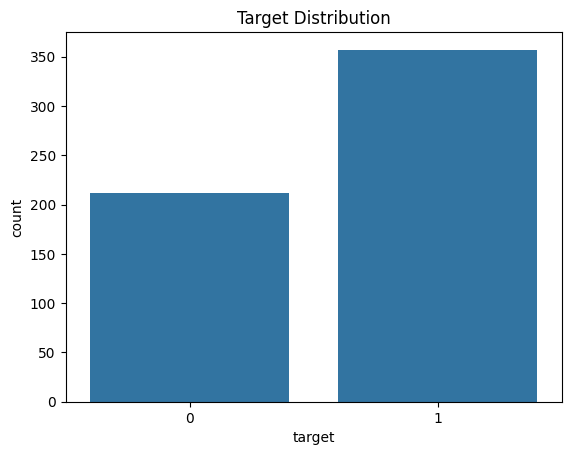

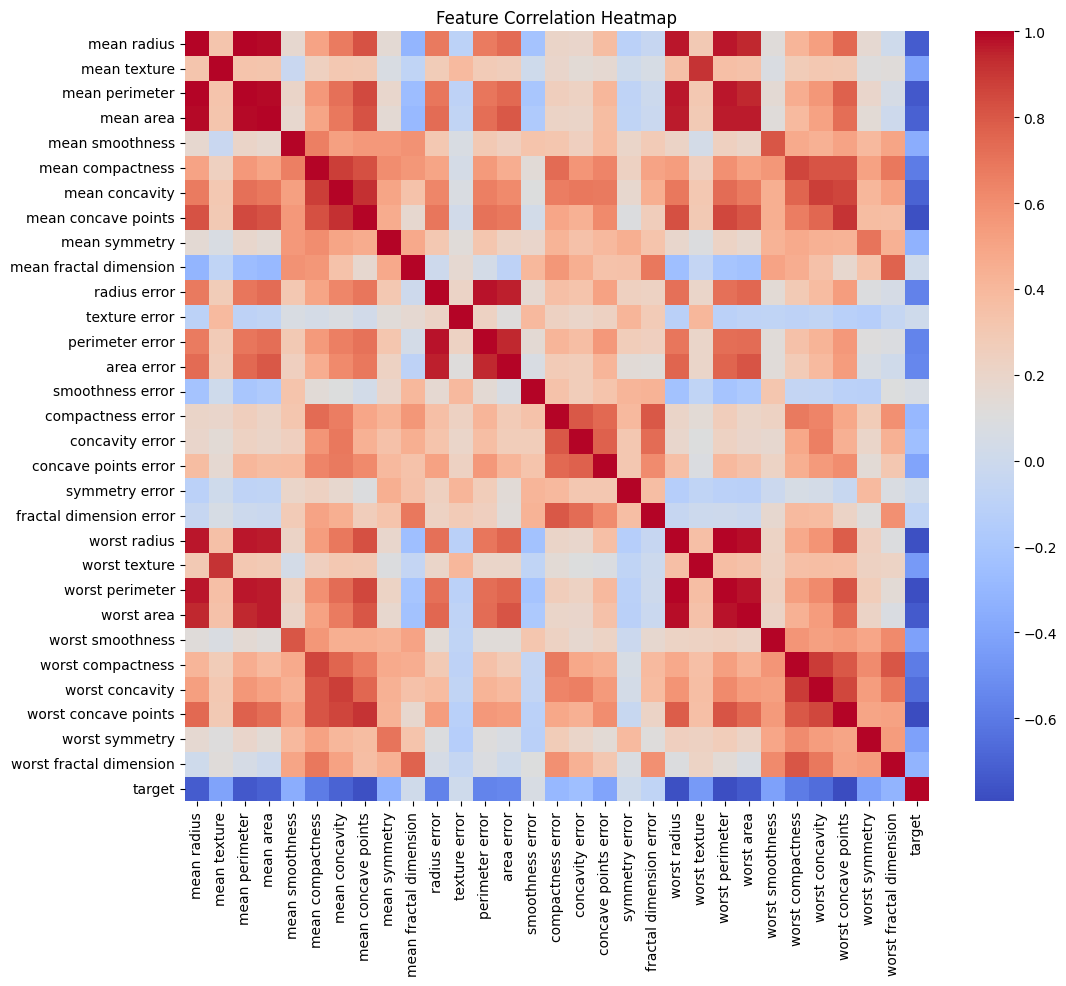

In [5]:
# ============================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

def perform_eda(df):
    """
    Perform EDA: info, stats, correlation
    """
    print("\nDataset Info:")
    print(df.info())

    print("\nStatistical Summary:")
    print(df.describe())

    # Target distribution
    plt.figure()
    sns.countplot(x='target', data=df)
    plt.title("Target Distribution")
    plt.show()

    # Correlation heatmap
    plt.figure(figsize=(12,10))
    sns.heatmap(df.corr(), cmap="coolwarm")
    plt.title("Feature Correlation Heatmap")
    plt.show()

perform_eda(data)

In [6]:
# ============================================
# PREPARE FEATURES & TARGET
# ============================================

def prepare_data(df):
    """
    Split dataset into features and target
    """
    X = df.drop("target", axis=1)
    y = df["target"]

    print("Feature shape:", X.shape)
    print("Target shape:", y.shape)

    return X, y

X, y = prepare_data(data)

Feature shape: (569, 30)
Target shape: (569,)


In [7]:
# ============================================
# SPLIT DATA
# ============================================

def split_data(X, y):
    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y   # important for classification
    )

X_train, X_test, y_train, y_test = split_data(X, y)

In [8]:
# ============================================
# TRAIN MODELS
# ============================================

def train_models(X_train, y_train):
    """
    Train Logistic Regression and Decision Tree
    """

    # Logistic Regression
    lr_model = LogisticRegression(max_iter=2000)
    lr_model.fit(X_train, y_train)

    # Decision Tree
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)

    return lr_model, dt_model

lr_model, dt_model = train_models(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# ============================================
# EVALUATE MODELS
# ============================================

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model using accuracy, confusion matrix, ROC
    """

    y_pred = model.predict(X_test)

    # Some models may not support predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{model_name} Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.9649


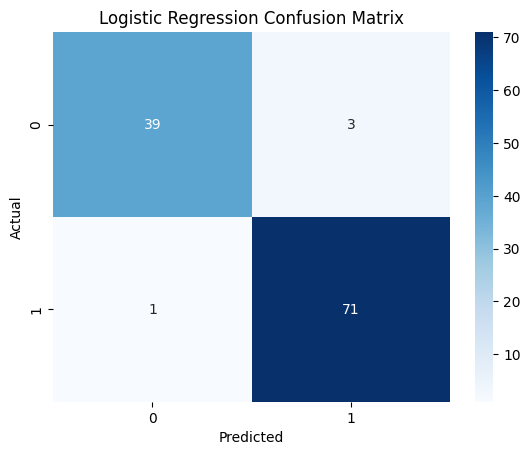

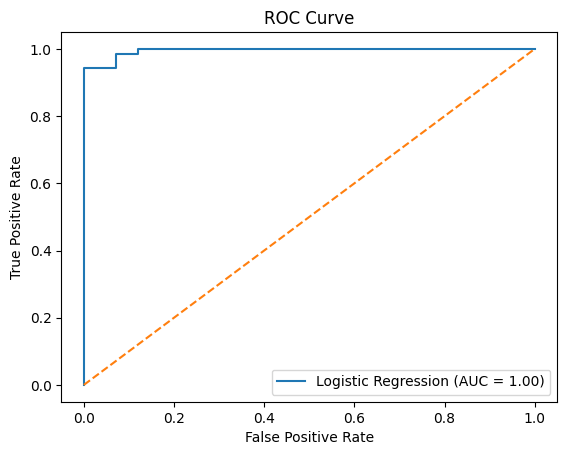


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Decision Tree Accuracy: 0.9123


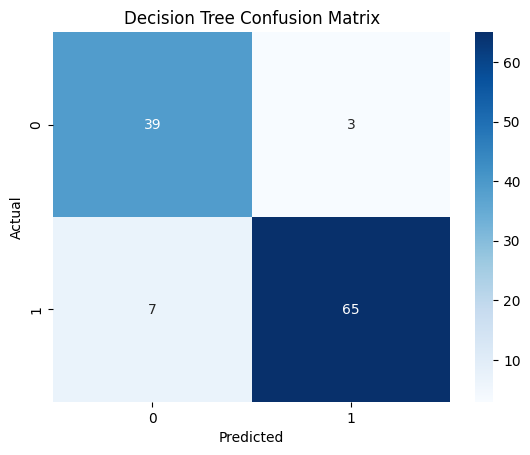

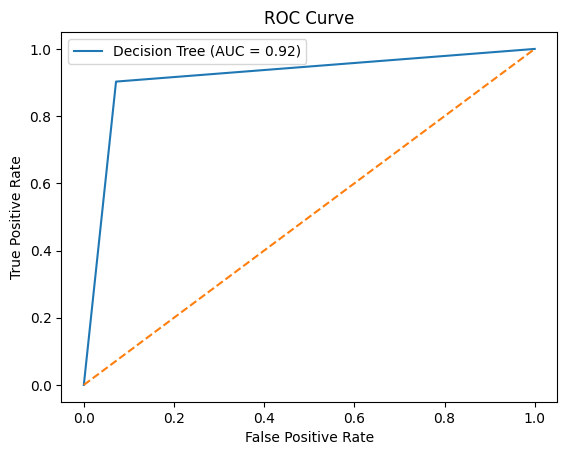


Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [11]:
evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(dt_model, X_test, y_test, "Decision Tree")

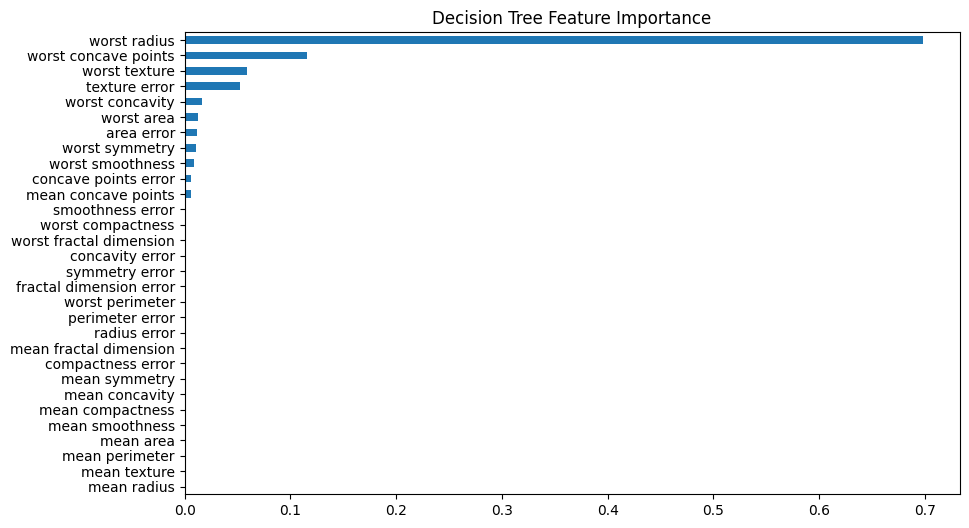

In [12]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

def plot_feature_importance(model, X, model_name):
    """
    Plot feature importance (Decision Tree)
    """

    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

        feat_importance = pd.Series(importance, index=X.columns)
        feat_importance = feat_importance.sort_values(ascending=True)

        plt.figure(figsize=(10,6))
        feat_importance.plot(kind='barh')
        plt.title(f"{model_name} Feature Importance")
        plt.show()

    else:
        print(f"{model_name} does not support feature importance")

plot_feature_importance(dt_model, X, "Decision Tree")